# 2. From cells to profiles

A screen produces millions of cells, and most analyses work on a few thousand well profiles.
This page covers the steps in between: quality control at three levels, normalization against
each plate's controls, and aggregation.

The data is a synthetic plate with known ground truth, generated locally, so each result on
this page can be checked against it.

In [1]:
import numpy as np

import mantispy as mt

adata = mt.ds.synthetic_plate(
    n_plates=2,
    n_wells=96,
    n_cells=60,
    n_features=80,
    n_images_per_well=2,
    n_bad_images=6,
    effect_size=2.0,
    nan_fraction=0.01,
    seed=0,
)
adata

AnnData object with n_obs × n_vars = 11520 × 80
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_Row', 'Metadata_Col', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch', 'Metadata_ImageNumber', 'Metadata_CellCount'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

The generator records everything it injected, and the checks below compare against that
record.

In [2]:
truth = adata.uns["mantispy"]["truth"]
{"bad images": len(truth["bad_images"]), "perturbations affected": len(truth["affected_features"])}

{'bad images': 6, 'perturbations affected': 9}

## Quality control at three levels

A cell can be bad, the image it came from can be bad, or the whole well can be. Each level
has its own function. None of them delete anything. They write flags, and you decide what to
drop.

### Images

`MeasureImageQuality` gives focus, saturation and dynamic-range statistics per field of
view. `image_qc` flags fields that are outliers within their own plate. Pooling plates would
flag every field on a uniformly dimmer plate and miss a blurred field on a bright one.

In [3]:
mt.pp.image_qc(adata, method="mad")
result = adata.uns["mantispy"]["image_qc"]
flagged = set(result.index[~result["qc_image_pass"]])
{"flagged": sorted(flagged), "injected": sorted(truth["bad_images"])}

{'flagged': [108, 178, 200, 263, 356, 376],
 'injected': [108, 178, 200, 263, 356, 376]}

It flagged the injected images and no others. `method="knn"` is the alternative. Instead of
asking whether any single metric is extreme, it asks whether a field's combination of metrics
is far from its neighbors, which catches images that are unusual overall without any one
metric standing out.

In [4]:
mt.pp.filter_images(adata)
adata.shape

(11340, 80)

### Cells

`calculate_qc_metrics` writes per-cell and per-feature statistics.

The most important one is `qc_nan_fraction`. Some missing values are normal in CellProfiler
output, because Zernike and radial-distribution features are undefined for objects below a
certain size. `qc_pass` therefore thresholds the fraction of missing features instead of
requiring none, which would fail almost every real cell.

In [5]:
mt.pp.calculate_qc_metrics(adata)
{
    "cells with some missing data": float((adata.obs["qc_n_nan_features"] > 0).mean()),
    "cells passing QC": float(adata.obs["qc_pass"].mean()),
}

{'cells with some missing data': 0.5429453262786597, 'cells passing QC': 1.0}

In [6]:
mt.pp.filter_cells(adata, min_cells_per_well=20)
mt.pp.filter_features(adata, min_variance=1e-8)
adata.shape

(11340, 80)

Nothing failed here: `qc_pass` is true for every cell and no feature is constant, so both
filters leave the shape unchanged. That is expected on a clean plate. The filters matter on
plates where cells or features do fail.

### Wells

`well_qc` summarizes each well: how many cells passed, how much data is missing and, for
control wells, how variable the controls are. High control variability is an early sign that
a well went wrong.

`control_cv` is a coefficient of variation, so it is only interpretable on positive raw
intensities. These synthetic features are centered near zero, which makes the ratio
unbounded, and that is why it reads 11 below instead of something like 0.1. Only read it on
raw CellProfiler intensities, before normalization.

In [7]:
mt.pp.well_qc(adata, min_cells=20)
adata.uns["mantispy"]["well_qc"].head()

,Metadata_Plate,Metadata_Well,n_cells,nan_fraction,control_cv,qc_well_pass
0,Plate01,A01,60,0.008750,11.381138,True
1,Plate01,A02,60,0.010625,NaN,True
2,Plate01,A03,60,0.010000,NaN,True
3,Plate01,A04,60,0.006875,NaN,True
4,Plate01,A05,60,0.008958,NaN,True


## Normalization

Plates differ in imaging day, reagent lot and microscope state. The standard fix is to express
every cell relative to the negative controls on its own plate, which is what
`reference="negcon"` together with `by="Metadata_Plate"` does.

The default method, `mad_robustize`, subtracts the control median and divides by a robust
spread, so a few extreme cells do not set the scale.

In [8]:
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon", keep_raw=True)

controls = adata[adata.obs["Metadata_Control"]]
np.round(np.nanmedian(np.asarray(controls.X), axis=0)[:5], 6)

array([-0.,  0.,  0., -0.,  0.], dtype=float32)

The controls now sit at zero on every plate by construction. `keep_raw=True` kept the
original values in `layers["raw"]` for the before-and-after plot. It is off by default
because the extra layer doubles memory and the original is already on disk.

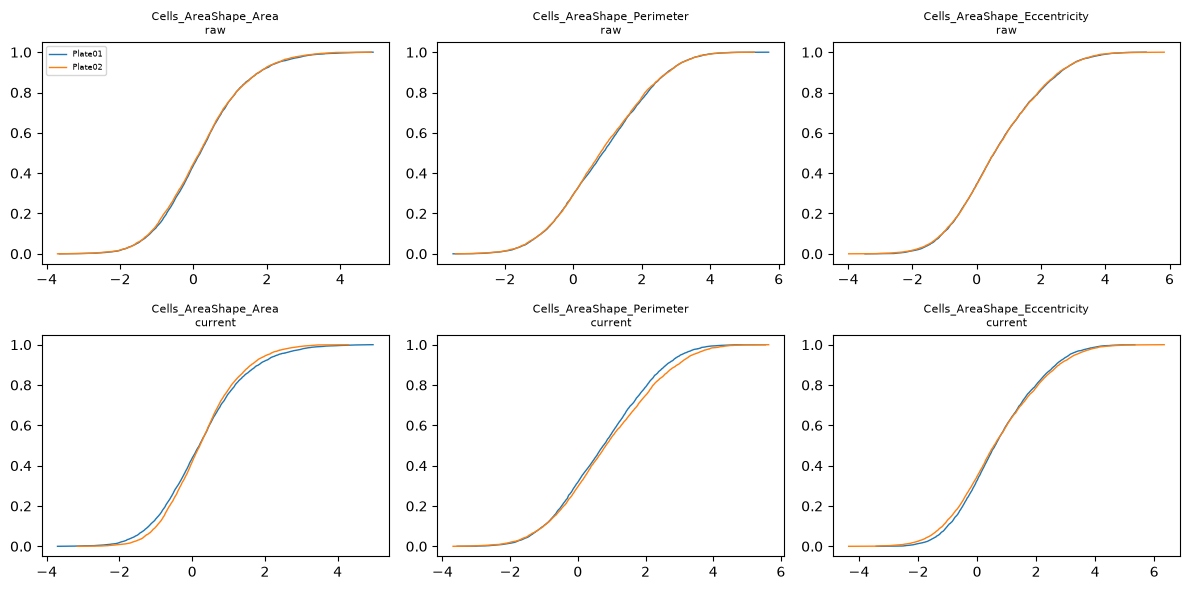

In [9]:
import matplotlib.pyplot as plt

mt.pl.feature_distributions(adata, features=list(adata.var_names[:3]))
plt.show()

## Aggregating to wells

Each well's profile is the median across its cells. The median is used instead of the mean so
that a few extreme cells do not move the profile.

In [10]:
wells = mt.tl.aggregate(adata, by=("Metadata_Plate", "Metadata_Well"), func="median")
wells

AnnData object with n_obs × n_vars = 192 × 80
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_CellCount', 'Metadata_Row', 'Metadata_Col', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'qc_n_nan', 'qc_variance', 'qc_n_unique', 'degenerate_scale'
    uns: 'mantispy'
    layers: None (.X)

The result records its provenance and keeps every metadata column that is constant within a
well. Columns that vary within a well, such as a per-cell measurement, are dropped because
they have no single value per well.

In [11]:
wells.uns["mantispy"]["aggregated_from"]

{'by': ['Metadata_Plate', 'Metadata_Well'],
 'func': 'median',
 'n_obs': 11340,
 'min_cells': 10}

`Metadata_CellCount` is added as well. Cell count is a common confounder, and
`mt.pp.regress_out` can remove its influence later.

## Looking at the plate

Plate layout artifacts are easiest to see on a plate map.

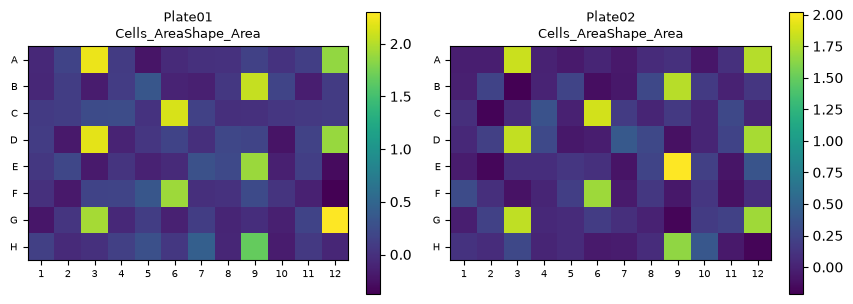

In [12]:
mt.pl.plate(wells, color=wells.var_names[0])
plt.show()

`pl.plate` draws any feature or `obs` column, so it also maps per-well flags, for example
`mt.pl.plate(wells, color="qc_well_pass")`.

## Handing off

`get.to_dataframe` returns the flat, metadata-first table that pycytominer,
cytominer-eval and most published scripts expect.

In [13]:
frame = mt.get.to_dataframe(wells)
frame.iloc[:3, :6]

,Metadata_Plate,Metadata_Well,Metadata_CellCount,Metadata_Row,Metadata_Col,Metadata_Perturbation
0,Plate01,A01,60,0,0,DMSO
1,Plate01,A02,60,0,1,pert00
2,Plate01,A03,60,0,2,pert01


Next: [3. Trustworthy profiles](03_trustworthy_profiles.ipynb), on reducing the features to
the informative ones.